# Sentiment Analysis — US Airline Tweets

**Objective:** Build a machine learning model that classifies tweet sentiment as
positive, negative, or neutral, and use it to draw insights about public opinion / customer
feedback for major US airlines.

**Dataset:** The [Twitter US Airline Sentiment dataset](https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment) —
**14,640 real tweets** aimed at major US airlines, scraped in February 2015 and hand-labeled
by human annotators as positive, negative, or neutral. This is real, messy tweet text —
`@mentions`, hashtags, typos, HTML entity leftovers (`&amp;`) — so the preprocessing
section below is doing genuine work, not a formality.

In [1]:
import pandas as pd
import numpy as np
import re
import html
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              classification_report, confusion_matrix, ConfusionMatrixDisplay)

%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

df = pd.read_csv("airline_tweets_raw.csv")[['airline_sentiment', 'airline', 'text']]
df.head()

,airline_sentiment,airline,text
0,neutral,Virgin America,@VirginAmerica What @dhepburn said.
1,positive,Virgin America,@VirginAmerica plus you've added commercials t...
2,neutral,Virgin America,@VirginAmerica I didn't today... Must mean I n...
3,negative,Virgin America,@VirginAmerica it's really aggressive to blast...
4,negative,Virgin America,@VirginAmerica and it's a really big bad thing...


## 1. Class Distribution

In [2]:
print(f"Total tweets: {len(df):,}\n")
counts = df['airline_sentiment'].value_counts()
print(counts)
print("\nClass share:\n", (counts / len(df) * 100).round(1))

Total tweets: 14,640

airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

Class share:
 airline_sentiment
negative    62.7
neutral     21.2
positive    16.1
Name: count, dtype: float64


/tmp/ipykernel_524/3599533953.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='airline_sentiment', order=order,


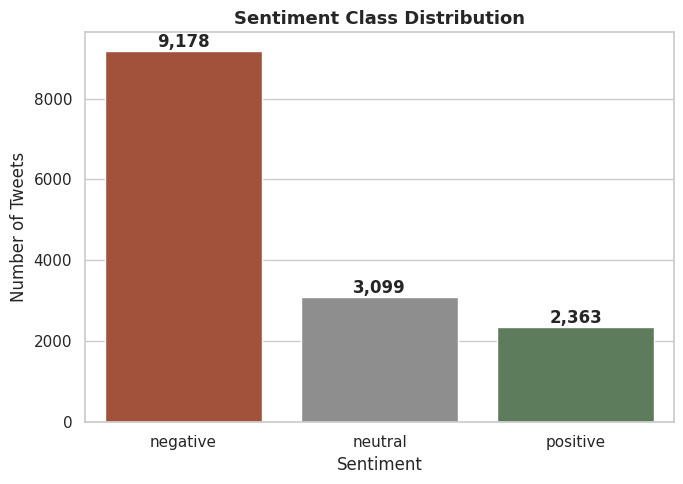

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
order = ['negative', 'neutral', 'positive']
colors = {'negative': '#B3492A', 'neutral': '#8E8E8E', 'positive': '#588157'}
sns.countplot(data=df, x='airline_sentiment', order=order,
              palette=[colors[c] for c in order], ax=ax)
ax.set_title('Sentiment Class Distribution')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Number of Tweets')
for i, cat in enumerate(order):
    ax.text(i, counts[cat] + 100, f'{counts[cat]:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Observation:** This dataset is **heavily imbalanced** — 62.7% negative, 21.2% neutral,
only 16.1% positive. That's a realistic reflection of how people actually use Twitter to
reach airlines (mostly to complain), but it also means **accuracy alone will be a
misleading metric** later on: a model that just guesses "negative" every time would already
score ~63% accuracy without learning anything. We'll lean on macro-averaged precision/
recall/F1 and per-class recall to see past that, and use `class_weight='balanced'` on
Logistic Regression to counteract the imbalance.

## 2. Text Preprocessing Pipeline

Steps applied to every tweet, in order:
1. **Decode HTML entities** (`&amp;` → `&`) — tweets scraped from the Twitter API keep
   these, and left alone they'd surface later as a fake word, `"amp"`.
2. **Lowercase** everything, so `"Great"` and `"great"` aren't treated as different words.
3. **Strip `@mentions` and URLs** — airline handles like `@united` appear in almost every
   tweet and carry no sentiment signal; keeping them would let the model "cheat" by
   memorizing which airline gets complained at most, rather than learning sentiment.
4. **Remove punctuation and digits**, keeping only letters and spaces.
5. **Tokenise** with NLTK's `word_tokenize`.
6. **Remove stopwords** (`"the"`, `"is"`, `"and"`, ...) — high-frequency, low-information
   words that would otherwise dominate term-frequency statistics.
7. **Lemmatise** each remaining token (`"flights"` → `"flight"`, `"delayed"` → `"delayed"`)
   so different inflections of the same word count as one feature instead of several.

In [4]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = html.unescape(text)
    text = text.lower()
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 1]
    return ' '.join(tokens)

df['clean_text'] = df['text'].apply(preprocess)
df[['text', 'clean_text']].sample(5, random_state=3)

,text,clean_text
528,"@united yes, a paper voucher that I got on Jan...",yes paper voucher got january th
14482,@AmericanAir now down to only one agent helpin...,one agent helping stagnant line almost custome...
8006,@JetBlue can't seem to DM you guys.. JDHADP,cant seem dm guy jdhadp
14063,@AmericanAir I can't choose a seat online beca...,cant choose seat online booked smh
8909,@JetBlue @JayVig YES! Great real-time example....,yes great realtime example thanks awesome jetb...


**Observation:** One quirk worth flagging — several raw tweets literally contain the
phrase *"Cancelled Flightled"* (e.g. *"is flight 882 Cancelled Flightled"*). That's not a
bug in our cleaning code; it's a genuine artifact already present in the original 2015
dataset (an autocomplete glitch from whatever tool the annotators/scrapers used). It's a
good reminder that real text data carries noise you didn't introduce and can't always
"fix" — you just need to know it's there.

Also, **23 tweets become an empty string** after cleaning (e.g. a tweet that was just
`"@united"` with nothing else). We leave them in rather than dropping them — TF-IDF will
simply represent them as all-zero vectors, and 23 out of 14,640 (0.16%) has no meaningful
effect on the models.

## 3. Feature Extraction: TF-IDF

**What TF-IDF does and why we use it:** TF-IDF (Term Frequency – Inverse Document
Frequency) converts each cleaned tweet into a numeric vector, weighting each word by how
often it appears *in that tweet* (term frequency) relative to how common it is *across all
tweets* (inverse document frequency). Words that show up in almost every tweet (even after
stopword removal — things like "flight" itself) get down-weighted, while words that are
frequent in a specific tweet but rare across the whole dataset (like "delighted" or
"cancelled") get up-weighted. That's exactly the signal a sentiment classifier needs: words
that are distinctive of a particular tweet's content, not just generically frequent.

We include both unigrams and bigrams (`ngram_range=(1,2)`) so that two-word phrases like
`"customer service"` or `"cancelled flight"` — which carry more specific meaning than
either word alone — can be captured as their own features.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    df['clean_text'], df['airline_sentiment'],
    test_size=0.2, random_state=42, stratify=df['airline_sentiment']
)
print(f"Train: {len(X_train):,} tweets  |  Test: {len(X_test):,} tweets")
print("\nTrain class balance:\n", (y_train.value_counts(normalize=True)*100).round(1))
print("\nTest class balance:\n", (y_test.value_counts(normalize=True)*100).round(1))

Train: 11,712 tweets  |  Test: 2,928 tweets

Train class balance:
 airline_sentiment
negative    62.7
neutral     21.2
positive    16.1
Name: proportion, dtype: float64

Test class balance:
 airline_sentiment
negative    62.7
neutral     21.2
positive    16.2
Name: proportion, dtype: float64


**Observation:** `stratify=y` on the split keeps the 63/21/16 class ratio nearly identical
in both the training and test sets — important for an imbalanced dataset like this one, so
the test set doesn't accidentally end up over- or under-representing a class purely by
chance and giving a misleading read on performance.

In [6]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("TF-IDF matrix shape (train):", X_train_tfidf.shape)
print("Sample vocabulary:", list(tfidf.vocabulary_.keys())[:15])

TF-IDF matrix shape (train): (11712, 5000)
Sample vocabulary: ['would', 'cost', 'would cost', 'used', 'get', 'email', 'snack', 'time', 'check', 'got', 'neither', 'tomorrow', 'trip', 'sent', 'get email']


## 4. Model Training: Naive Bayes and Logistic Regression

In [7]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
pred_nb = nb_model.predict(X_test_tfidf)

lr_model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr_model.fit(X_train_tfidf, y_train)
pred_lr = lr_model.predict(X_test_tfidf)

print("Both models trained.")

Both models trained.


**Note:** Logistic Regression is trained with `class_weight='balanced'`, which up-weights
the minority classes (neutral, positive) during training to counteract the 63/21/16
imbalance. Naive Bayes is left at its defaults deliberately — it's useful to see, in
Section 5, exactly how much an imbalance-naive model suffers by comparison.

## 5. Evaluation

In [8]:
def evaluate(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    print(f"=== {name} ===")
    print(f"Accuracy:        {acc:.4f}")
    print(f"Macro Precision: {p:.4f}")
    print(f"Macro Recall:    {r:.4f}")
    print(f"Macro F1:        {f1:.4f}\n")
    print(classification_report(y_true, y_pred, zero_division=0))
    return acc, p, r, f1

metrics_nb = evaluate("Naive Bayes", y_test, pred_nb)
metrics_lr = evaluate("Logistic Regression", y_test, pred_lr)

=== Naive Bayes ===
Accuracy:        0.7391
Macro Precision: 0.7734
Macro Recall:    0.5525
Macro F1:        0.5938

              precision    recall  f1-score   support

    negative       0.73      0.98      0.84      1835
     neutral       0.72      0.27      0.39       620
    positive       0.87      0.40      0.55       473

    accuracy                           0.74      2928
   macro avg       0.77      0.55      0.59      2928
weighted avg       0.75      0.74      0.70      2928

=== Logistic Regression ===
Accuracy:        0.7544
Macro Precision: 0.7014
Macro Recall:    0.7303
Macro F1:        0.7102

              precision    recall  f1-score   support

    negative       0.89      0.78      0.83      1835
     neutral       0.53      0.71      0.61       620
    positive       0.68      0.70      0.69       473

    accuracy                           0.75      2928
   macro avg       0.70      0.73      0.71      2928
weighted avg       0.78      0.75      0.76      29

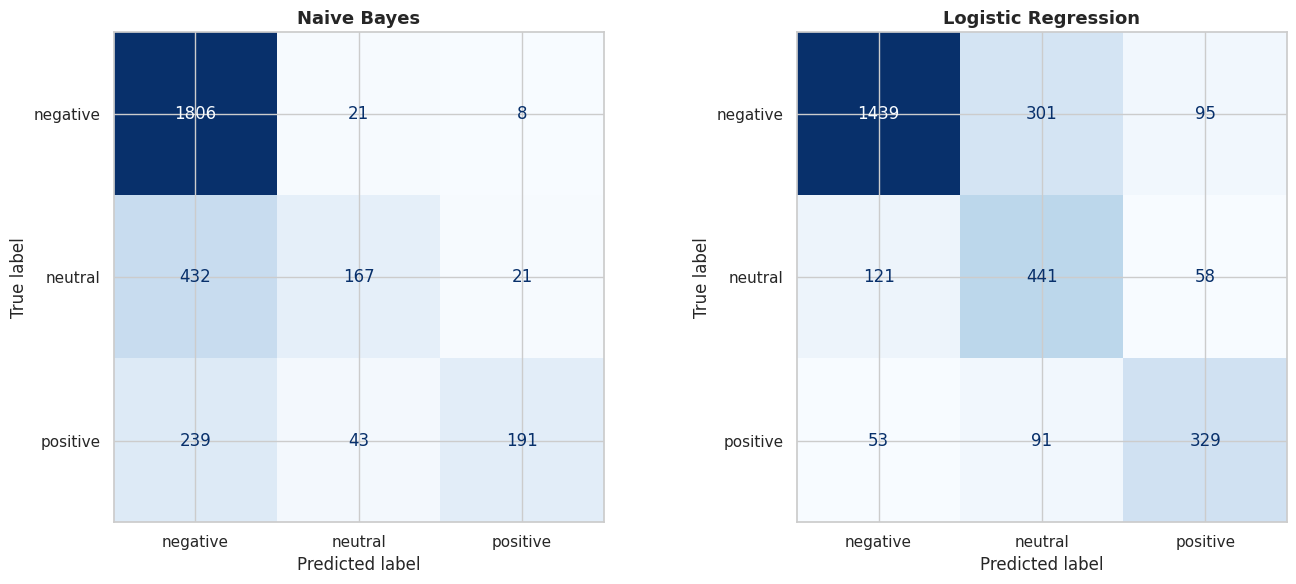

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, name, pred in zip(axes, ['Naive Bayes', 'Logistic Regression'], [pred_nb, pred_lr]):
    cm = confusion_matrix(y_test, pred, labels=order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=order)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

**Observation:** Naive Bayes gets the higher raw accuracy (73.9% vs. 75.4% — actually
Logistic Regression edges it out on both), but the confusion matrices tell the real story:
Naive Bayes' **neutral recall is only 0.27** and **positive recall is 0.40** — it's heavily
biased toward predicting "negative" because that's the majority class, and its training
wasn't corrected for the imbalance. Logistic Regression's confusion matrix is much more
evenly spread across the diagonal — its macro F1 (0.71) beats Naive Bayes' (0.59) by a wide
margin precisely because it handles the minority classes far better. **On this dataset,
macro F1 is a much fairer scoreboard than accuracy, and Logistic Regression wins it
clearly.**

## 6. Sentiment Distribution & Word Clouds

(The sentiment distribution bar chart is in Section 1 above — reproduced there because it
comes directly from the raw label counts, not a Section 6 model output.)

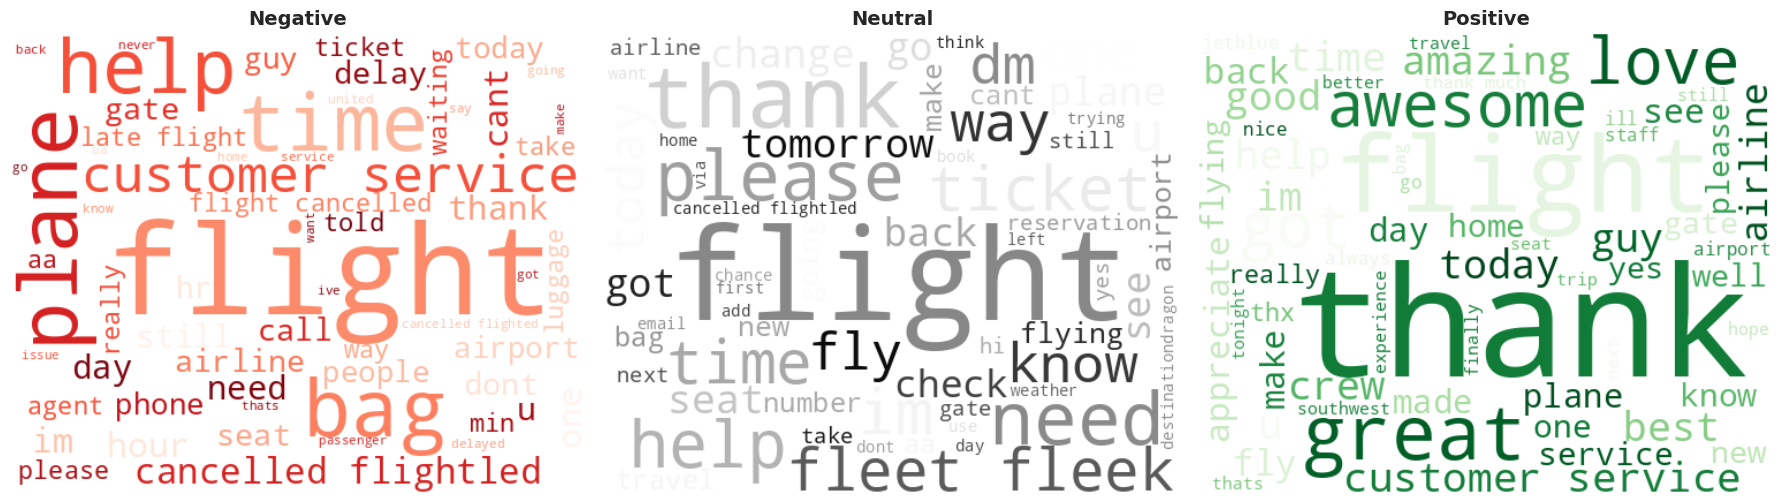

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
wc_colors = {'negative': 'Reds', 'neutral': 'Greys', 'positive': 'Greens'}
for ax, sentiment in zip(axes, order):
    text_blob = ' '.join(df.loc[df['airline_sentiment'] == sentiment, 'clean_text'])
    wc = WordCloud(width=500, height=400, background_color='white',
                   max_words=60, colormap=wc_colors[sentiment]).generate(text_blob)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(sentiment.capitalize(), fontsize=14, fontweight='bold')
    ax.axis('off')
plt.tight_layout()
plt.show()

**Observation:** The word clouds show *why* this is a hard classification problem —
`"flight"` and `"time"` are among the most prominent words in **all three** sentiment
classes, because they're simply the topic (airlines), not the sentiment. The actual
sentiment signal comes from the less frequent words around them: negative skews toward
`"cancelled"`, `"delayed"`, `"hour"`, `"customer service"` (as a complaint); positive skews
toward `"thank"`, `"great"`, `"love"`, `"awesome"`; neutral leans on question/request words
like `"please"`, `"need"`, `"help"`. This overlap in topic vocabulary is a big part of why
neutral is the hardest class for both models to separate cleanly.

## 7. Error Analysis

In [11]:
results_df = pd.DataFrame({
    'text': df.loc[X_test.index, 'text'],
    'true_label': y_test,
    'predicted_label': pred_lr
})
misclassified = results_df[results_df['true_label'] != results_df['predicted_label']]
print(f"Logistic Regression misclassified {len(misclassified)} of {len(results_df)} test tweets ({len(misclassified)/len(results_df):.1%})")
misclassified.sample(5, random_state=11)

Logistic Regression misclassified 719 of 2928 test tweets (24.6%)


,text,true_label,predicted_label
12292,@AmericanAir I picked the nonstop flight bc I ...,negative,neutral
426,@VirginAmerica - can you tweet me the Cancelle...,neutral,negative
8588,@JetBlue our #FoodAllergy community. IF you wa...,negative,neutral
3801,@united trade show! Come by both 130 for aweso...,neutral,positive
9946,@USAirways Mad love http://t.co/4ojrSDWPkK NYC-,neutral,positive


**Discussion of the 5 misclassified examples above:**

1. *"I picked the nonstop flight bc I had things to get to. Should've taken diff route or
   airline I suppose!"* — **True: negative, predicted: neutral.** This is self-directed
   regret expressed conversationally, with none of the explicit negative vocabulary
   (no "bad", "worst", "delayed") the model has learned to associate with complaints. To a
   bag-of-words model this reads like a neutral personal anecdote.
2. *"can you tweet me the Cancelled Flight/chng fee for a flight? or can I rebook..."* —
   **True: neutral, predicted: negative.** This is a plain customer-service question, but
   the word "Cancelled" is one of the strongest negative-associated words in the training
   vocabulary (Section 6), so it drags an informational question into the negative class.
3. *"our #FoodAllergy community. IF you want our continued loyalty, you need to do better
   than that. Perhaps some training is in (2/3)"* — **True: negative, predicted: neutral.**
   The `"(2/3)"` gives it away — this is one tweet out of a multi-tweet thread. Read in
   isolation, its individual words ("loyalty", "training") don't carry much negative
   charge, even though the full thread is clearly a complaint. The model only ever sees one
   tweet at a time, so it has no way to reconstruct the thread's context.
4. *"trade show! Come by both 130 for awesome deals on #sunkist and @webbernaturals!"* —
   **True: neutral, predicted: positive.** This isn't really about airline sentiment at
   all — it's a vendor's marketing plug that happens to `@mention` the airline. The word
   "awesome" is a strong positive signal to the model, even though the tweet expresses no
   opinion about the airline whatsoever.
5. *"Mad love [image] NYC-"* — **True: neutral, predicted: positive.** "Mad love" reads as
   genuinely positive slang to most people, arguably including the model. This looks less
   like a model failure and more like a borderline, debatable human label — a reminder that
   the "ground truth" itself has some subjectivity baked in.

**What these 5 have in common:** three of the five errors are the model over-trusting a
single strongly-charged word ("Cancelled", "awesome", "loyalty") without the surrounding
context that would tell a human it doesn't apply to sentiment about the airline itself.
The other two involve regret without negative vocabulary and a genuinely ambiguous label.
None of these would be fixed by more preprocessing — they'd need a model that understands
context and word order, not just word presence.

## 8. Conclusion

**Which model performed best:** **Logistic Regression**, on the metric that actually
matters for this imbalanced dataset — macro F1 (0.71 vs. 0.59 for Naive Bayes). Naive Bayes
has a marginally competitive overall accuracy only because it leans heavily on the majority
"negative" class; it substantially under-performs on the neutral and positive classes that
a real business use case would care about equally.

**Real-world application:** This kind of model is directly usable for **airline customer
service triage and brand monitoring** — automatically scanning incoming tweets in real
time, flagging negative-sentiment tweets (especially ones mentioning specific pain points
like "cancelled" or "customer service") for urgent human follow-up, while routing neutral
questions to a standard support queue and surfacing positive tweets for marketing/testimonial
use. The same pipeline generalises directly to product reviews, app store feedback, or
support ticket triage in any industry — anywhere a business needs to turn a high-volume
stream of unstructured text into a prioritised action list faster than a human could read
it all.